# Import **Libraries**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# **Dataset**

In [18]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Missing Values
print("Missing Values in X_train:", np.isnan(X_train).sum())
print("Missing Values in X_test:", np.isnan(X_test).sum())

# Reshape
X_train = X_train.reshape(X_train.shape[0], 28*28)
X_test = X_test.reshape(X_test.shape[0], 28*28)

# Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.LongTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# TensorDataset
from torch.utils.data import TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Missing Values in X_train: 0
Missing Values in X_test: 0


# Exp **1**

In [19]:
#Step 3
#Multilayer Perceptron (MLP)
model = nn.Sequential(
    nn.Linear(784, 256),    #Input -> Hidden 1
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),


    nn.Linear(256, 128),     #Hidden 2
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(128, 64),      #Output

)
print(model)


Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
)


In [20]:
# Loss , Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
#Training ,
# Lists for visualization

train_losses1 = []
val_losses1 = []

train_accuracies1 = []
val_accuracies1 = []

epochs = 40

# Initialize variables for early stopping and best model tracking
best_val_loss = float('inf')
patience = 15
counter = 0
best_model_state = None

for epoch in range(epochs):

    # --- Training Phase ---
    model.train()
    total_train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        # Flatten the input batch
        X_batch = X_batch.view(X_batch.size(0), -1)
        # Forward Pass
        outputs = model(X_batch)

        # Loss
        loss = criterion(outputs, y_batch)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == y_batch).sum().item()
        train_total += y_batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # --- Validation Phase ---
    model.eval()
    val_epoch_loss = 0
    val_epoch_correct = 0
    val_epoch_total = 0
    with torch.no_grad():
        X_val_flat = X_val.view(X_val.size(0), -1)
        val_outputs = model(X_val_flat)
        val_loss = criterion(val_outputs, y_val.long().squeeze())
        val_epoch_loss = val_loss.item()

        _, val_predicted = torch.max(val_outputs, 1)
        val_epoch_correct = (val_predicted == y_val.long().squeeze()).sum().item()
        val_epoch_total = y_val.size(0)

    val_accuracy = 100 * val_epoch_correct / val_epoch_total
    train_losses1.append(avg_train_loss)
    val_losses1.append(val_epoch_loss)

    train_accuracies1.append(train_acc)
    val_accuracies1.append(val_accuracy)

    # --- Test Phase ---
    test_epoch_loss = 0
    test_epoch_correct = 0
    test_epoch_total = 0
    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            X_batch_test = X_batch_test.view(X_batch_test.size(0), -1)
            outputs_test = model(X_batch_test)
            loss_test = criterion(outputs_test, y_batch_test)
            test_epoch_loss += loss_test.item()

            _, predicted_test = torch.max(outputs_test, 1)
            test_epoch_correct += (predicted_test == y_batch_test).sum().item()
            test_epoch_total += y_batch_test.size(0)

    avg_test_loss = test_epoch_loss / len(test_loader)
    test_accuracy = 100 * test_epoch_correct / test_epoch_total

    # --- Early Stopping Logic ---
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print(f"Early Stopping at epoch {epoch+1}")
        break

    # --- Print Epoch Results ---
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

# Optionally, load the best model state after training
if best_model_state:
    model.load_state_dict(best_model_state)
    print("Loaded best model based on validation loss.")

Epoch 1 | Train Loss: 0.5626 | Train Acc: 81.86% | Val Loss: 0.3815 | Val Acc: 85.62% | Test Loss: 0.4136 | Test Acc: 84.77%
Epoch 2 | Train Loss: 0.3904 | Train Acc: 85.73% | Val Loss: 0.3372 | Val Acc: 87.60% | Test Loss: 0.3637 | Test Acc: 86.75%
Epoch 3 | Train Loss: 0.3502 | Train Acc: 87.17% | Val Loss: 0.3235 | Val Acc: 87.97% | Test Loss: 0.3505 | Test Acc: 87.03%
Epoch 4 | Train Loss: 0.3262 | Train Acc: 88.02% | Val Loss: 0.3175 | Val Acc: 88.09% | Test Loss: 0.3371 | Test Acc: 87.56%
Epoch 5 | Train Loss: 0.3082 | Train Acc: 88.46% | Val Loss: 0.3081 | Val Acc: 88.57% | Test Loss: 0.3329 | Test Acc: 87.92%
Epoch 6 | Train Loss: 0.2946 | Train Acc: 89.06% | Val Loss: 0.3050 | Val Acc: 88.87% | Test Loss: 0.3285 | Test Acc: 88.30%
Epoch 7 | Train Loss: 0.2819 | Train Acc: 89.52% | Val Loss: 0.3026 | Val Acc: 88.76% | Test Loss: 0.3321 | Test Acc: 88.14%
Epoch 8 | Train Loss: 0.2686 | Train Acc: 89.99% | Val Loss: 0.3008 | Val Acc: 89.06% | Test Loss: 0.3270 | Test Acc: 88.25%


In [22]:
#Testing
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
      for X_batch , y_batch in test_loader :

        X_batch = X_batch.view(X_batch.size(0), -1)

      # Forward Pass
        outputs = model(X_batch)

      #Loss
        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

      #Accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 89.46%


# Exp **2**

In [23]:
#Step 3
#Multilayer Perceptron (MLP)
model = nn.Sequential(
    nn.Linear(784, 256),    #Input -> Hidden 1
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),


    nn.Linear(256, 128),     #Hidden 2
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(128, 64),      #Output

)
print(model)


Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
)


In [24]:
# Loss , Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [25]:
# Lists for visualization

train_losses2 = []
val_losses2 = []

train_accuracies2 = []
val_accuracies2 = []

epochs = 40

# Initialize variables for early stopping and best model tracking
best_val_loss = float('inf')
patience = 15
counter = 0
best_model_state = None

for epoch in range(epochs):

    # --- Training Phase ---
    model.train()
    total_train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        # Flatten the input batch
        X_batch = X_batch.view(X_batch.size(0), -1)
        # Forward Pass
        outputs = model(X_batch)

        # Loss
        loss = criterion(outputs, y_batch)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == y_batch).sum().item()
        train_total += y_batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # --- Validation Phase ---
    model.eval() # Set model to evaluation mode
    val_epoch_loss = 0
    val_epoch_correct = 0
    val_epoch_total = 0
    with torch.no_grad():
        X_val_flat = X_val.view(X_val.size(0), -1)
        val_outputs = model(X_val_flat)
        val_loss = criterion(val_outputs, y_val.long().squeeze())
        val_epoch_loss = val_loss.item()

        _, val_predicted = torch.max(val_outputs, 1)
        val_epoch_correct = (val_predicted == y_val.long().squeeze()).sum().item()
        val_epoch_total = y_val.size(0)

    val_accuracy = 100 * val_epoch_correct / val_epoch_total
    train_losses2.append(avg_train_loss)
    val_losses2.append(val_epoch_loss)

    train_accuracies2.append(train_acc)
    val_accuracies2.append(val_accuracy)

    # --- Test Phase ---
    test_epoch_loss = 0
    test_epoch_correct = 0
    test_epoch_total = 0
    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            X_batch_test = X_batch_test.view(X_batch_test.size(0), -1)
            outputs_test = model(X_batch_test)
            loss_test = criterion(outputs_test, y_batch_test)
            test_epoch_loss += loss_test.item()

            _, predicted_test = torch.max(outputs_test, 1)
            test_epoch_correct += (predicted_test == y_batch_test).sum().item()
            test_epoch_total += y_batch_test.size(0)

    avg_test_loss = test_epoch_loss / len(test_loader)
    test_accuracy = 100 * test_epoch_correct / test_epoch_total

    # --- Early Stopping Logic ---
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print(f"Early Stopping at epoch {epoch+1}")
        break

    # --- Print Epoch Results ---
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

# load the best model state after training
if best_model_state:
    model.load_state_dict(best_model_state)
    print("Loaded best model based on validation loss.")

Epoch 1 | Train Loss: 1.2093 | Train Acc: 76.20% | Val Loss: 0.5508 | Val Acc: 83.96% | Test Loss: 0.5689 | Test Acc: 83.08%
Epoch 2 | Train Loss: 0.5081 | Train Acc: 84.15% | Val Loss: 0.4145 | Val Acc: 85.67% | Test Loss: 0.4386 | Test Acc: 84.80%
Epoch 3 | Train Loss: 0.4221 | Train Acc: 85.67% | Val Loss: 0.3709 | Val Acc: 86.88% | Test Loss: 0.3962 | Test Acc: 86.07%
Epoch 4 | Train Loss: 0.3822 | Train Acc: 86.76% | Val Loss: 0.3548 | Val Acc: 87.07% | Test Loss: 0.3767 | Test Acc: 86.31%
Epoch 5 | Train Loss: 0.3538 | Train Acc: 87.58% | Val Loss: 0.3333 | Val Acc: 87.92% | Test Loss: 0.3575 | Test Acc: 87.19%
Epoch 6 | Train Loss: 0.3335 | Train Acc: 88.14% | Val Loss: 0.3242 | Val Acc: 88.32% | Test Loss: 0.3458 | Test Acc: 87.39%
Epoch 7 | Train Loss: 0.3151 | Train Acc: 88.63% | Val Loss: 0.3220 | Val Acc: 88.25% | Test Loss: 0.3463 | Test Acc: 87.33%
Epoch 8 | Train Loss: 0.3032 | Train Acc: 89.15% | Val Loss: 0.3127 | Val Acc: 88.38% | Test Loss: 0.3331 | Test Acc: 87.90%


In [26]:
#Testing
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
      for X_batch , y_batch in test_loader :

        X_batch = X_batch.view(X_batch.size(0), -1)

      # Forward Pass
        outputs = model(X_batch)

      #Loss
        loss = criterion(outputs, y_batch)
        test_loss += loss.item() # Using test_loss

      #Accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

# These lines were incorrectly indented. Moving them outside the `with` block and aligning to 0 indentation.
avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 89.37%


#Visualization Exp 1

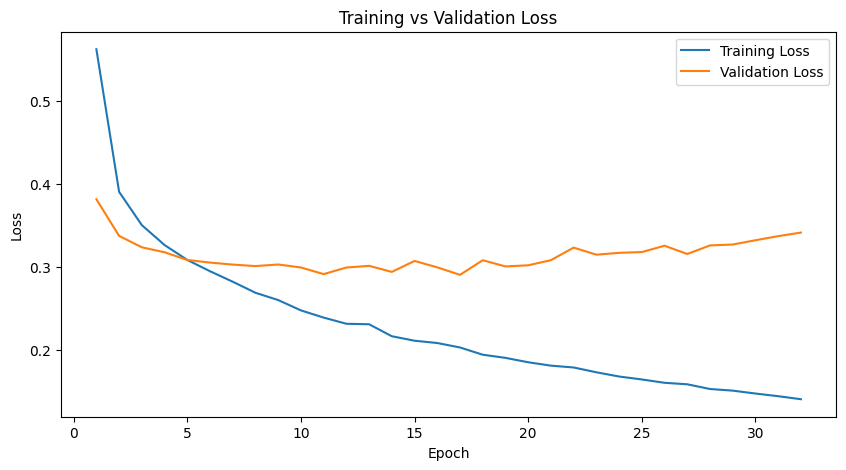

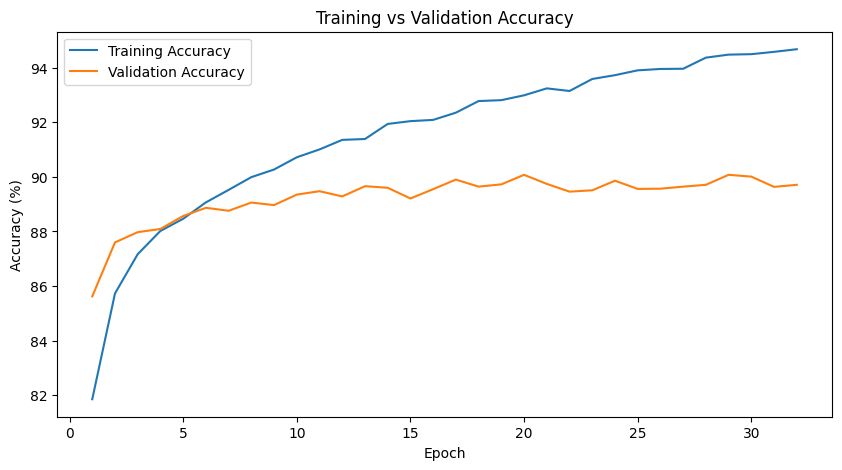

In [27]:
# Visualization
epochs_range = range(1, len(train_losses1) + 1)

# Loss Curves
plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_losses1, label="Training Loss")
plt.plot(epochs_range, val_losses1, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# Accuracy Curves
plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_accuracies1, label="Training Accuracy")
plt.plot(epochs_range, val_accuracies1, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

#Visualization Exp 2

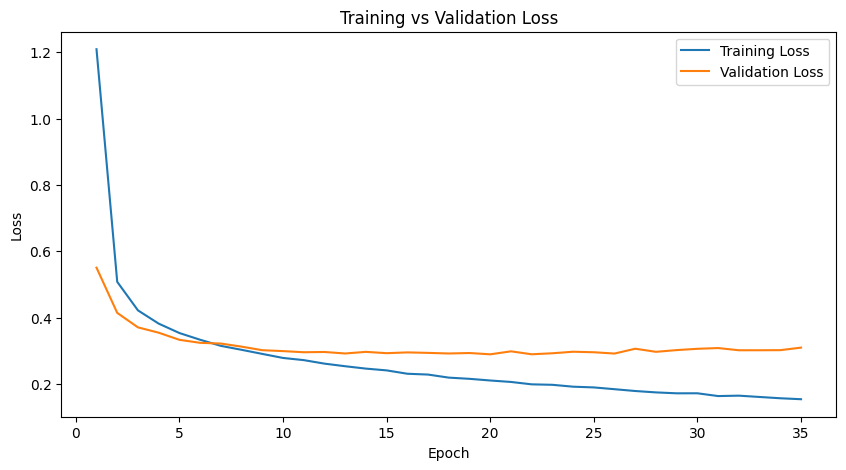

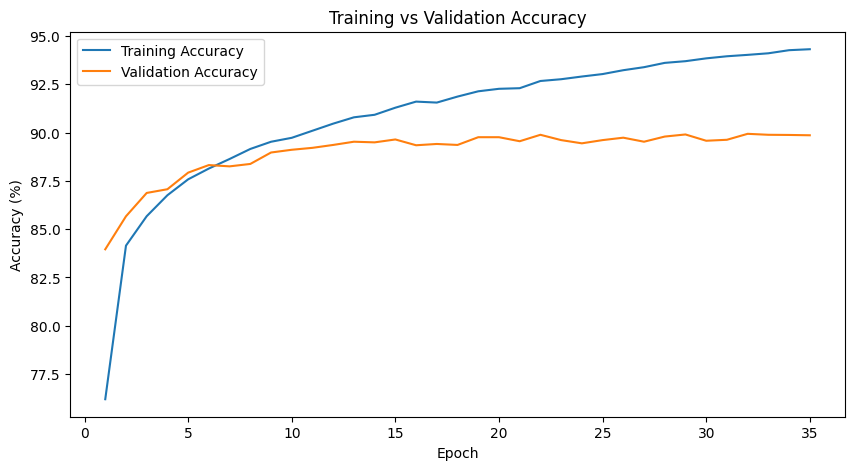

In [28]:
# Visualization
epochs_range = range(1, len(train_losses2) + 1)

# Loss Curves
plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_losses2, label="Training Loss")
plt.plot(epochs_range, val_losses2, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# Accuracy Curves
plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_accuracies2, label="Training Accuracy")
plt.plot(epochs_range, val_accuracies2, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()